In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec, LdaModel, CoherenceModel
from kneed import KneeLocator
from gensim import corpora
import numpy as np
import re
import pandas as pd


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

In [3]:
# === Download necessary NLTK data ===
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [4]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()  # ✅ Fix: Use split() instead of word_tokenize()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [5]:
combined_details_df = pd.read_csv("../frontend/data/combined_details.csv", encoding='utf-8')

In [6]:
combined_details_df.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,34.0,210.0,363.0,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0
1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,1.0,0.0,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0
2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,5.0,31.0,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0
3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,43.0,98.0,127.0,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0
4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,6.0,46.0,58.0,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0


In [10]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_67108/3197724261.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [11]:
combined_details_df['tags']

0               history museum specialty museum
1                                      bar club
2                              sacred religious
3                                     boat tour
4                                    body water
                         ...                   
1761                                      beach
1762                                     bridge
1763    sacred religious architectural building
1764                                      beach
1765                                    lookout
Name: tags, Length: 1766, dtype: object

In [12]:
# แปลงข้อมูลเป็น String
tags = combined_details_df['tags'].astype(str)

# ใช้ TF-IDF Vectorizer
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.lower().split(" "), stop_words='english')

# Fit Transform
X = vectorizer.fit_transform(tags)

# ดึง Feature Names (คำที่สำคัญ)
feature_names = np.array(vectorizer.get_feature_names_out())

# คำนวณ TF-IDF และเลือกคำที่มีค่ามากที่สุดในแต่ละแถว
important_words = []
for row in X:
    row_data = row.toarray().flatten()
    best_word_index = np.argmax(row_data)  # Index ของคำที่สำคัญที่สุด
    best_word = feature_names[best_word_index] if row_data[best_word_index] > 0 else None
    important_words.append(best_word)

# เพิ่มคอลัมน์ใหม่
combined_details_df["keyword"] = important_words

# ดูผลลัพธ์
(combined_details_df[["name", "tags", "keyword"]].head(10))

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,name,tags,keyword
0,House of Opium,history museum specialty museum,museum
1,Opium Bar,bar club,bar
2,Wat Phra That Doi Saket,sacred religious,religious
3,Mae Ping River Cruise,boat tour,boat
4,Pai River,body water,body
5,Doi Chang Mub Arboretum,lookout,lookout
6,Tung Dok Bua Tong Doi Hua Mae Kum,garden,garden
7,Golden Triangle,other,None
8,Golden Triangle Tours - Day Tours,sightseeing tour,sightseeing
9,Bo Nam Ron Krung Ching,hot spring geyser,geyser


In [13]:
from collections import Counter

# รวมแท็กทั้งหมดเป็น List (แก้เป็น .split(", ") แทน .split(" "))
all_tags = [tag.strip() for tags in combined_details_df['tags'].dropna() for tag in tags.lower().split(", ")]

# นับความถี่ของแต่ละคำ
tag_counts = Counter(all_tags)

# ฟังก์ชันเลือกคำที่พบบ่อยที่สุดในแถว
def select_most_frequent(tag_string):
    tags = tag_string.lower().split(", ")  # แก้ให้แยกคำตาม ", "
    return max(tags, key=lambda tag: tag_counts[tag]) if tags else None

# ใช้ฟังก์ชันกับทุกแถว
combined_details_df["frequncy_keyword"] = combined_details_df["tags"].astype(str).apply(select_most_frequent)

# ดูผลลัพธ์
print(combined_details_df[["tags", "frequncy_keyword"]].head())

                              tags                 frequncy_keyword
0  history museum specialty museum  history museum specialty museum
1                         bar club                         bar club
2                 sacred religious                 sacred religious
3                        boat tour                        boat tour
4                       body water                       body water


In [14]:
tag_counts

Counter({'other': 223,
         'sacred religious': 210,
         'flea street market': 80,
         'spa': 76,
         'beach': 75,
         'specialty museum': 69,
         'gift specialty shop': 64,
         'nature wildlife area': 48,
         'waterfall': 45,
         'shopping mall': 28,
         'lookout': 27,
         'monument statue': 25,
         'island': 25,
         'bar club': 24,
         'park': 24,
         'body water': 23,
         'farm': 20,
         'cavern cave': 19,
         'national park': 17,
         'cooking class': 17,
         'historic': 16,
         'nature wildlife tour': 16,
         'history museum': 15,
         'scuba snorkeling': 14,
         'farmer market': 13,
         'mountain': 13,
         'garden': 12,
         'boat tour': 11,
         'zoo': 11,
         'golf course': 10,
         'bridge': 10,
         'taxi shuttle': 10,
         'ferry': 10,
         'hot spring geyser': 9,
         'neighborhood': 9,
         'art gallery': 9,
   

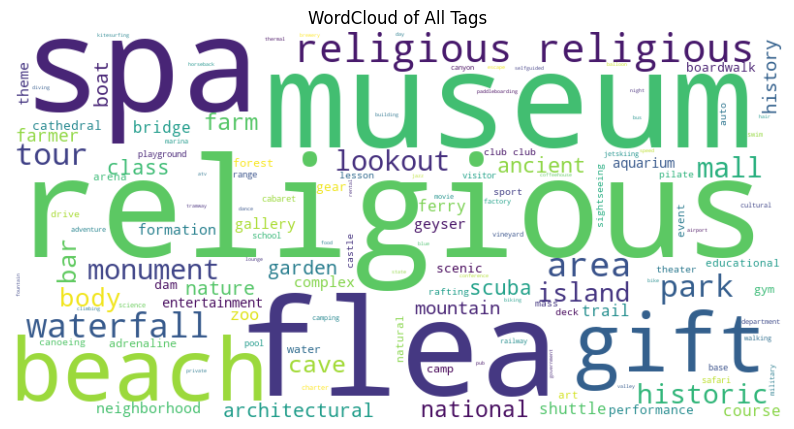

In [15]:
all_text = " ".join(combined_details_df['keyword'].dropna())
# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

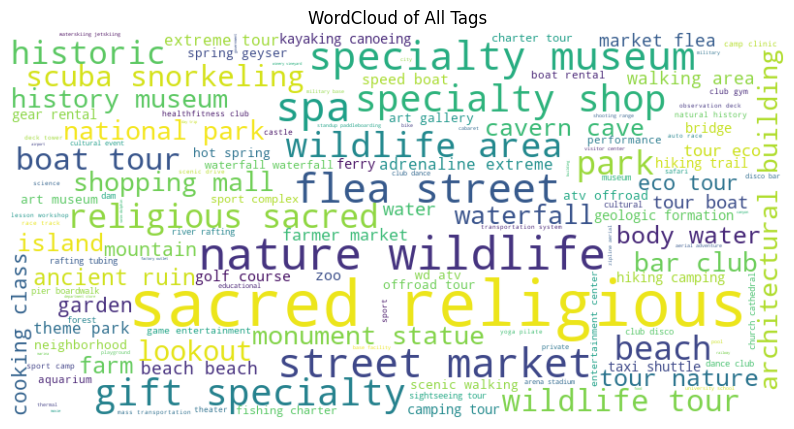

In [16]:
all_text = " ".join(combined_details_df['tags'].dropna())
# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

## Experiment - [TF-IDF + K-MEAN + LDA]

In [18]:
docs = combined_details_df["keyword"].dropna().tolist()

In [19]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(combined_details_df['keyword'].fillna(''))

In [20]:
# ✅ 3. แปลงเป็น Gensim Corpus
terms = vectorizer.get_feature_names_out()
corpus = [dict(zip(terms, row.toarray().flatten())) for row in X]

# ✅ 4. สร้าง Dictionary ของ Gensim
id2word = corpora.Dictionary([list(d.keys()) for d in corpus])
corpus_gensim = [id2word.doc2bow(text.keys()) for text in corpus]

In [21]:
perplexities = []
coherence_scores = []
topic_range = range(2, 30)  # กำหนดช่วงของจำนวนหัวข้อ (2 ถึง 30)

# for n_topics in topic_range:
#     lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
#     lda_model.fit(X)
#     perplexities.append(lda_model.perplexity(X))

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus_gensim,
        id2word=id2word,
        num_topics=num_topics,
        random_state=42,
        passes=10,
    )

    coherence_model = CoherenceModel(
        model=lda_model, texts=[list(d.keys()) for d in corpus], dictionary=id2word, coherence="c_v"
    )

    coherence_scores.append(coherence_model.get_coherence())


In [24]:
coherence_scores 

# [0.594936759112231,
#  0.6102762055026069,
#  0.6305658546543125,
#  0.6579377118381166,
#  0.6647330321478798,
#  0.6164492360232234,
#  0.634514589251938,
#  0.6369882533803762,
#  0.6468262047638477,
#  0.643341164369208,
#  0.6227831985484021,
#  0.6149773008618395,
#  0.6268953553423016,
#  0.6416585720972964,
#  0.6380053802675031,
#  0.6391979636725407,
#  0.6564609277397302,
#  0.6501006452479361,
#  0.6376302334591026,
#  0.6386697868243223,
#  0.6352341200720707,
#  0.6483412539253768,
#  0.6447467988248526,
#  0.6420966069201818,
#  0.6387531224428776,
#  0.6360516681560787,
#  0.638769883530309,
#  0.6328682791456121]

[0.594936759112231,
 0.6102762055026069,
 0.6305658546543125,
 0.6579377118381166,
 0.6647330321478798,
 0.6164492360232234,
 0.634514589251938,
 0.6369882533803762,
 0.6468262047638477,
 0.643341164369208,
 0.6227831985484021,
 0.6149773008618395,
 0.6268953553423016,
 0.6416585720972964,
 0.6380053802675031,
 0.6391979636725407,
 0.6564609277397302,
 0.6501006452479361,
 0.6376302334591026,
 0.6386697868243223,
 0.6352341200720707,
 0.6483412539253768,
 0.6447467988248526,
 0.6420966069201818,
 0.6387531224428776,
 0.6360516681560787,
 0.638769883530309,
 0.6328682791456121]

In [41]:
optimal_topics = topic_range[np.argmax(coherence_scores)]
print(f"Best number of topics: {optimal_topics}")

Best number of topics: 6


In [42]:
knee_locator = KneeLocator(topic_range, coherence_scores, curve="concave", direction="increasing")
optimal_elbow_topics = knee_locator.knee
print(f"Optimal number of topics: {optimal_elbow_topics}")

Optimal number of topics: 6


In [43]:
threshold = max(coherence_scores) * 0.8  # กรองเฉพาะค่าที่มากกว่า 80% ของค่าสูงสุด
valid_topics = [n for n, score in zip(topic_range, coherence_scores) if score >= threshold]
optimal_filtered_topics = min(valid_topics, key=lambda x: abs(x - optimal_topics))

print(f"Filtered Optimal Topics: {optimal_filtered_topics}")


Filtered Optimal Topics: 6


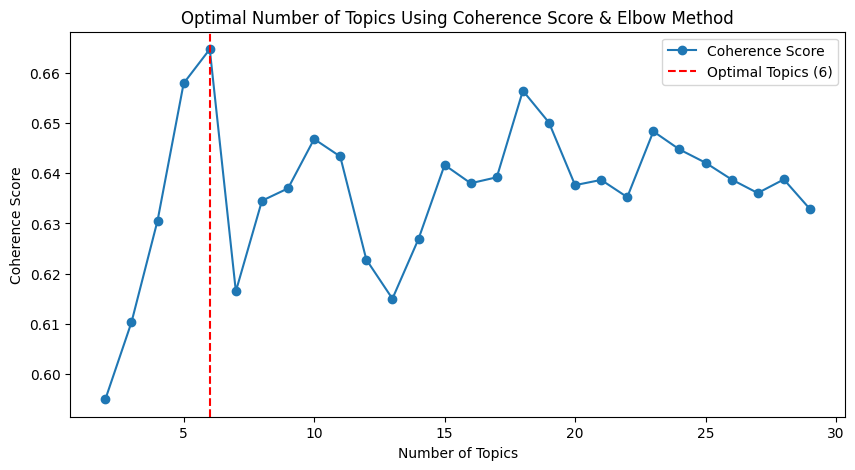

In [33]:
# knee_locator = KneeLocator(topic_range, coherence_scores, curve="convex", direction="decreasing")
# optimal_topics = knee_locator.knee
# print(f"Optimal number of topics: {optimal_topics}")

# ✅ 7. วาดกราฟแสดง Elbow Point
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores, marker="o", label="Coherence Score")
plt.axvline(x=optimal_topics, color="r", linestyle="--", label=f"Optimal Topics ({optimal_topics})")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics Using Coherence Score & Elbow Method")
plt.legend()
plt.show()

In [ ]:
# perplexity_changes = np.diff(perplexities)

# # หา "Elbow Point" = จุดที่ค่าความชันลดลงมากที่สุด
# # elbow_k = topic_range[np.argmin(perplexity_changes) + 1]  # +1 เพราะ np.diff ลด index ไป 1
# # elbow_perplexity = perplexities[np.argmin(perplexity_changes) + 1]

# second_derivative = np.diff(perplexity_changes)

# # หา Elbow Point โดยดูค่าการเร่งที่สูงสุด (absolute)
# elbow_k = topic_range[np.argmax(abs(second_derivative)) + 2]  # +2 เพราะ np.diff ใช้ 2 รอบ
# elbow_perplexity = perplexities[np.argmax(abs(second_derivative)) + 2]

# # สร้างกราฟ
# plt.figure(figsize=(10, 6))
# plt.plot(topic_range, perplexities, marker='o', label="Perplexity")
# plt.axvline(x=elbow_k, color='green', linestyle='--', label=f'Elbow Point = {elbow_k}')
# plt.scatter(elbow_k, elbow_perplexity, color='green', s=100, zorder=3)

# # ตั้งค่ากราฟ
# plt.title('LDA Perplexity vs Number of Topics')
# plt.xlabel('Number of Topics')
# plt.ylabel('Perplexity')
# plt.xticks(topic_range, rotation=45)
# plt.grid()
# plt.legend()
# plt.show()

# print(f'Optimal Number of Topics: {elbow_k}')

# N_CLUSTER = elbow_k


In [ ]:
N_CLUSTER = optimal_filtered_topics

In [53]:
# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['keyword'] = combined_details_df['keyword'].fillna('')
combined_details_df['keyword'].replace("", "other", inplace=True)

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
# vectorizer = TfidfVectorizer()
# X = vectorizer.fit_transform(combined_details_df['keyword'])

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(combined_details_df['keyword']) 

# สร้างโมเดล LDA เพื่อหา topics
lda_model = LatentDirichletAllocation(n_components=optimal_topics, random_state=42)
lda_model.fit(X)

# ดึง top keywords ในแต่ละ topic
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda_model, vectorizer.get_feature_names_out(), n_top_words=10)

# กำหนดกลุ่มให้แต่ละสถานที่
combined_details_df['topic'] = lda_model.transform(X).argmax(axis=1)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_67108/1404148418.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['keyword'].replace("", "other", inplace=True)


Topic 0:
waterfall park monument island bar class architectural course aquarium scenic
Topic 1:
body farm national nature boat ferry gear performance club forest
Topic 2:
gift area history farmer neighborhood cathedral boardwalk camp event natural
Topic 3:
flea spa ancient garden zoo geyser entertainment educational arena rafting
Topic 4:
religious museum lookout trail shuttle gallery theme gym auto school
Topic 5:
beach tour mall historic cave scuba mountain bridge formation complex


In [54]:
def get_topic_words(lda_model, feature_names, n_top_words=11):
    topic_words = []
    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lda_model, vectorizer.get_feature_names_out(), n_top_words=20)

In [55]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Convert Scikit-Learn LDA Model to Gensim Format
tokenized_docs = [text.split() for text in combined_details_df['keyword']]
dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

# Train LDA using Gensim (instead of Scikit-Learn)
lda_model_gensim = LdaModel(corpus=corpus, id2word=dictionary, num_topics=optimal_topics, passes=10)

vis = gensimvis.prepare(lda_model_gensim, corpus, dictionary)
pyLDAvis.display(vis)


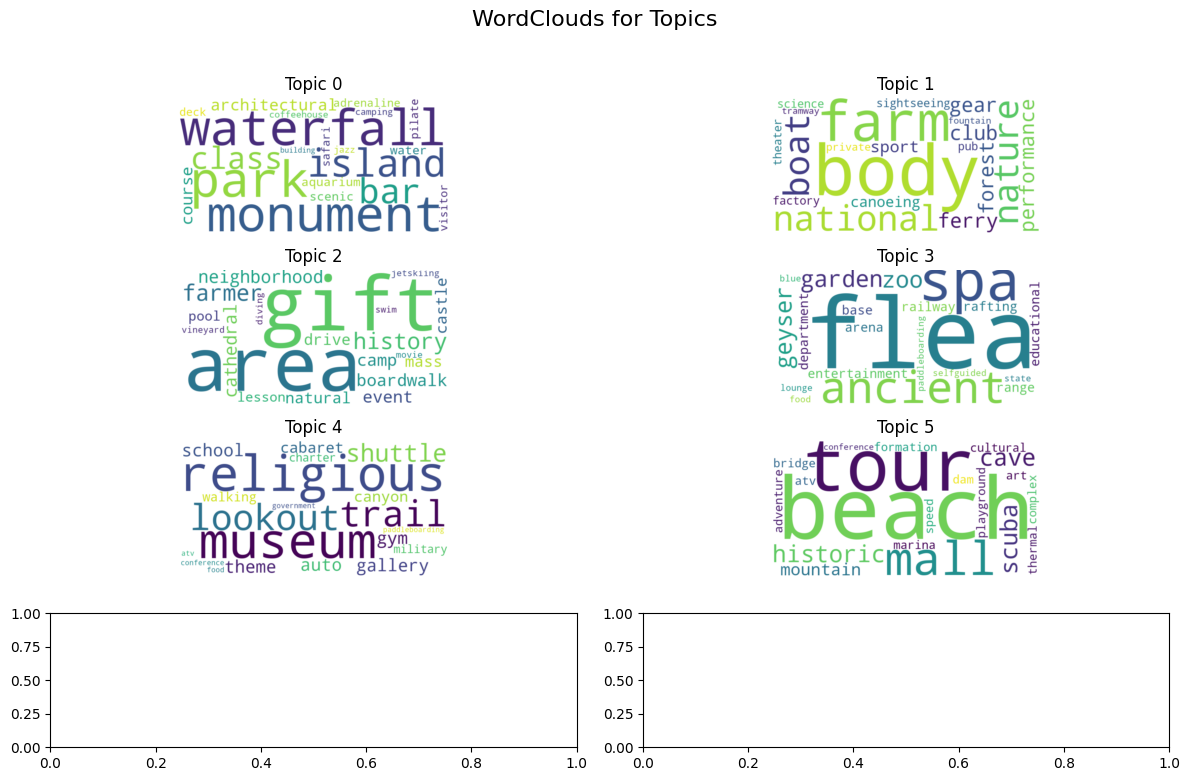

In [56]:
def plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16, y=0.97)  # Adjust title position

    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes

    # Adjust the layout
    plt.subplots_adjust(hspace=0.4, wspace=0.3)  # Reduce vertical (hspace) and horizontal (wspace) gaps
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout and leave space for title
    plt.show()

plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2)

In [57]:
topic_words

['waterfall park monument island bar class architectural course aquarium scenic water adrenaline deck pilate safari visitor camping coffeehouse jazz building',
 'body farm national nature boat ferry gear performance club forest sport canoeing sightseeing theater science factory pub private tramway fountain',
 'gift area history farmer neighborhood cathedral boardwalk camp event natural mass castle drive lesson pool jetskiing swim movie vineyard diving',
 'flea spa ancient garden zoo geyser entertainment educational arena rafting range base railway department selfguided lounge state blue food paddleboarding',
 'religious museum lookout trail shuttle gallery theme gym auto school cabaret canyon walking military charter paddleboarding food government conference atv',
 'beach tour mall historic cave scuba mountain bridge formation complex dam art playground cultural marina adventure speed thermal atv conference']

In [61]:
# ✅ Assign each word in topic_words to its cluster ID
word_topic_map = {}
for topic_idx, words in enumerate(topic_words):
    for word in words.split():
        word_topic_map[word] = topic_idx  # Assign each word to a topic

# ✅ Train Word2Vec Model
sentences = [tags.split(", ") for tags in combined_details_df['keyword'].dropna()]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=0)

# ✅ Extract Word Vectors & Cluster Labels (Only Words in Both topic_words & Word2Vec)
words = [word for word in word_topic_map.keys() if word in model.wv]
word_vectors = np.array([model.wv[word] for word in words])
word_clusters = np.array([word_topic_map[word] for word in words])

# ✅ Reduce Dimensions with PCA (100D → 30D)
pca = PCA(n_components=30)
word_vectors_pca = pca.fit_transform(word_vectors)

# ✅ Adjust t-SNE Perplexity Based on Data Size
recommended_perplexity = max(min(len(word_vectors) // 3, 50), 5)  # Between 5 and 50
reducer = TSNE(n_components=2, perplexity=recommended_perplexity, random_state=42)

# ✅ Apply t-SNE
word_vectors_2d = reducer.fit_transform(word_vectors_pca)


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
num_clusters = len(topic_words)
palette = sns.color_palette("husl", num_clusters)  # Generate distinct colors

# ✅ Scatter plot with cluster colors
for cluster_id in range(num_clusters):
    idx = word_clusters == cluster_id
    plt.scatter(word_vectors_2d[idx, 0], word_vectors_2d[idx, 1], label=f"Cluster {cluster_id}",
                color=palette[cluster_id], alpha=0.8, edgecolors='k', linewidth=0.5)

# ✅ Annotate words more clearly
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.75)

# ✅ Improve visualization settings
plt.title("Improved Word2Vec Clustering Visualization (t-SNE with Coherence Score)")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.legend()
plt.show()

NameError: name 'topic_words' is not defined

<Figure size 1200x800 with 0 Axes>

In [63]:
perplexity = lda_model.perplexity(X)  # X is the TF-IDF matrix or document-term matrix
print(f"Perplexity: {perplexity}")

Perplexity: 79.38311196400943


In [65]:
combined_details_df[['name', 'tags', 'keyword', 'frequncy_keyword', 'topic']]

,name,tags,keyword,frequncy_keyword,topic
0,House of Opium,history museum specialty museum,museum,history museum specialty museum,4
1,Opium Bar,bar club,bar,bar club,0
2,Wat Phra That Doi Saket,sacred religious,religious,sacred religious,4
3,Mae Ping River Cruise,boat tour,boat,boat tour,1
4,Pai River,body water,body,body water,1
...,...,...,...,...,...
1761,Chao Lao Beach,beach,beach,beach,5
1762,Chao Lao Fish Bridge,bridge,bridge,bridge,5
1763,Wat Burapa Temple,sacred religious architectural building,architectural,sacred religious architectural building,0
1764,Kung Wiman Beach,beach,beach,beach,5


In [19]:
combined_details_df.to_parquet("output/lda_clusters.parquet", index=False)